# Problem 03: 
Tiến hành kỹ thuật Feature Engineering, tìm ra các thuộc tính có tính chất colinearity (linearly dependent). Huấn luyện lại  phương pháp hồi quy tuyến tính với bộ dữ liệu chỉ giữ lại các thuộc tính uncorrelated.

In [64]:
import numpy as np
import pandas as pd 
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [65]:
df = pd.read_csv('forestfires.csv')

In [66]:
#  Covert days into numerical values

def convert_day(day: str)->int:
    day_dict = {
        'mon' : 1,
        'tue' : 2,
        'wed' : 3,
        'thu' : 4,
        'fri' : 5,
        'sat' : 6,
        'sun' : 7,
    }
    return day_dict[day]
# Covert months into numerical values

def convert_month(month: str)->int:
    month_dict = {
        "jan" : 1,
        "feb" : 2,
        "mar" : 3,
        "apr" : 4,
        "may" : 5,
        "jun" : 6,
        "jul" : 7,
        "aug" : 8,
        "sep" : 9,
        "oct" : 10,
        "nov" : 11,
        "dec" : 12,
    }
    return month_dict[month]
df['day'] = df['day'].apply(convert_day)
df['month'] = df['month'].apply(convert_month)
df.head(5)

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,3,5,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,10,2,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,10,6,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,3,5,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,3,7,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [ ]:
# Divide dataset into training data and testing data (80/20)
X_y = df.to_numpy()
N = df.shape[0]

X_y_train, X_y_test = np.split(X_y, indices_or_sections=[int(0.8 * N)])
X_train, X_test = X_y_train[:, :-1], X_y_test[:, :-1]  
Y_train, Y_test = X_y_train[:, -1], X_y_test[:, -1] 

In [68]:
# Create DataFrame including only feature
feature_names = df.columns[: -1]
df_features = pd.DataFrame(X_train, columns = feature_names)

In [69]:
# Correlation Matrix
corr_matrix = df_features.corr().abs()

In [70]:
# Create mask to take values from top triangle of the matrix
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k = 1). astype(bool))

In [71]:
# Find feature with correlation rate > 0.8
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.8)]
print(to_drop)

['DC']


In [72]:
# Drop feature with high correlation rate
df_features_reduced = df_features.drop(columns = to_drop)
# Check VIF (Variance Inflation Factor) to find out if any variable is too linearly dependent on others 
vif_data = pd.DataFrame()
vif_data["Feature"] = df_features_reduced.columns
vif_data["VIF"] = [variance_inflation_factor(df_features_reduced.values, i) for i in range(df_features_reduced.shape[1])]
print(vif_data)


   Feature        VIF
0        X   7.507566
1        Y  17.818586
2    month  15.203826
3      day   5.368607
4     FFMC  72.368368
5      DMC   7.762825
6      ISI   6.294969
7     temp  30.343625
8       RH  12.628321
9     wind   6.511884
10    rain   1.060946


In [73]:
high_vif_features = vif_data[vif_data["VIF"] > 10]["Feature"].tolist()
high_vif_features

['Y', 'month', 'FFMC', 'temp', 'RH']

In [74]:
# Back to Numpy
df_features_final = df_features_reduced
X_train_final = df_features_final.to_numpy()
# X_test_final = pd.DataFrame(X_test, columns=feature_names).to_numpy()
X_test_final = df_features_final.iloc[:X_test.shape[0], :].to_numpy()

In [75]:
print(X_train_final.shape)  
print(X_test_final.shape)   

(413, 11)
(104, 11)


In [76]:
# Standardize data
df['FFMC'] = (df['FFMC'] - df['FFMC'].mean()) / df['FFMC'].std()
df['DMC'] = (df['DMC'] - df['DMC'].mean()) / df['DMC'].std()

In [77]:
# Standardize using sklearn
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
columns_to_standardize = ['ISI', 'temp', 'RH', 'wind', 'rain']
df[columns_to_standardize] = scaler.fit_transform(df[columns_to_standardize])

In [78]:
# Using log transformation to normalize because 'area' (skewed - lean toward 0.0) is not following normal distribution
df['area'] = np.log1p(df['area'])

In [79]:
# Algorithm
class LinearRegression:
    def __init__(self):
        self.theta = None
        
    def rmse(self, y: np.ndarray, y_hat:np.ndarray) -> float: # Loss function
        # Root Mean Squared Error 
        delta = y - y_hat
        return np.square(delta).mean()**0.5
    
    def fit(self, X: np.ndarray, Y: np.ndarray) -> None: # Training model
        cov = np.matmul(X.T, X)
        inv_cov = np.linalg.inv(cov)
        self.theta = np.matmul(np.matmul(inv_cov, X.T), Y)
        
    def predict(self, X: np.ndarray) -> np.ndarray:
        y_pred = np.matmul(self.theta.T, X.T)
        return y_pred
    def evaluate(self, X: np.ndarray, Y: np.ndarray) -> float:
        y_pred = self.predict(X)
        return self.rmse(Y, y_pred)


In [80]:
model = LinearRegression()
# Training model
model.fit(X_train_final, Y_train)

# Predict in testing dataset
y_pred = model.predict(X_test_final)

# Evaluate model
rmse_value = model.evaluate(X_test_final, Y_test)
print(f'RMSE: {rmse_value:.6f}')


RMSE: 80.441195


Matplotlib is building the font cache; this may take a moment.


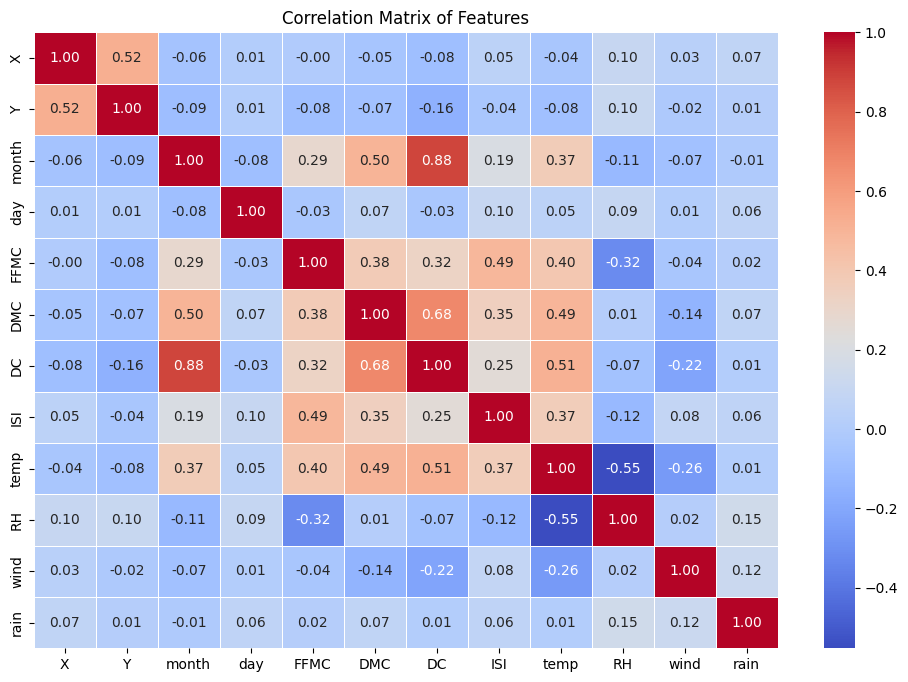

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

# Tính ma trận tương quan
corr_matrix = df_features.corr()

# Vẽ heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Features")
plt.show()